# **Mounting Drive and Importing Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install opencv-python


In [ ]:
import os
import re
import zipfile
import datetime
import unicodedata
from collections import defaultdict
from difflib import SequenceMatcher

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, models
from scipy import ndimage
from skimage import measure
from transformers import T5Tokenizer, T5ForConditionalGeneration


# **Image Cleaning**

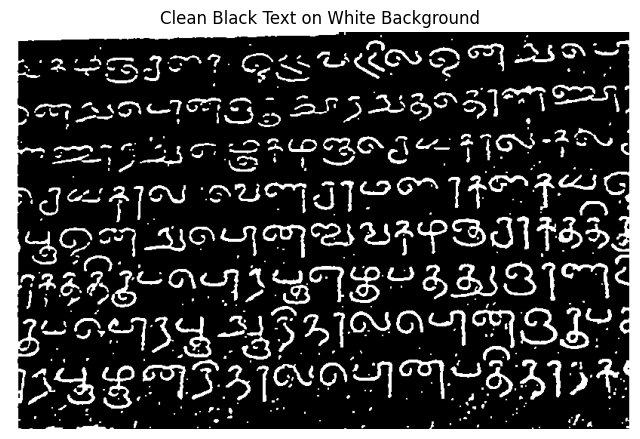

Processed image saved as: text_cleaned.png


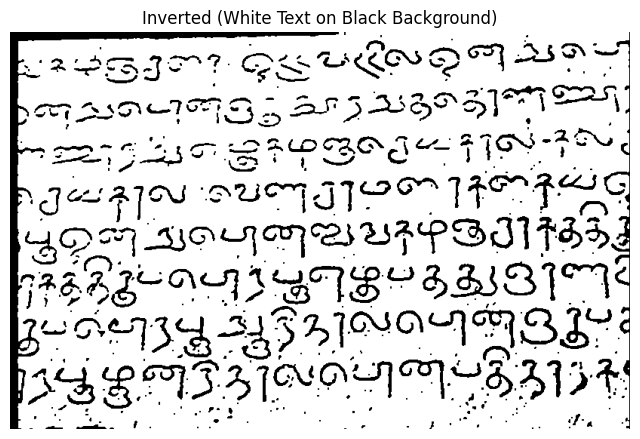

Inverted image saved as: inverted.png


In [ ]:
def clean_text_image(input_path, output_path="text_cleaned.png"):
    # Load image
    image = cv2.imread(input_path)

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blur (reduces background noise)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Use Otsu’s threshold (good for high contrast text)
    _, bw = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Invert to make background white, text black
    bw = cv2.bitwise_not(bw)

    # Morphological operations to remove small noise
    kernel = np.ones((2,2), np.uint8)
    bw = cv2.morphologyEx(bw, cv2.MORPH_OPEN, kernel, iterations=1)  # remove small dots
    bw = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, kernel, iterations=1) # strengthen letters

    # Save & show
    cv2.imwrite(output_path, bw)

    plt.figure(figsize=(8, 6))
    plt.imshow(bw, cmap="gray")
    plt.title("Clean Black Text on White Background")
    plt.axis("off")
    plt.show()

    print(f"Processed image saved as: {output_path}")
    return bw

# Usage
bw_result = clean_text_image("/content/Tamil Inscription.jpg")

def invert_bw(input_path, output_path="inverted.png", show=True):
    # Load as grayscale
    image = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)

    # Invert colors
    inverted = cv2.bitwise_not(image)

    # Save if needed
    # cv2.imwrite(output_path, inverted)

    if show:   # show only once
        plt.figure(figsize=(8,6))
        plt.imshow(inverted, cmap="gray")
        plt.title("Inverted (White Text on Black Background)")
        plt.axis("off")
        plt.show()

    print(f"Inverted image saved as: {output_path}")
    return inverted

_ = invert_bw("/content/text_cleaned.png")


# **Image Segmentation**

IMPROVED HANDWRITTEN TEXT SEGMENTATION

Starting advanced character segmentation...
Image shape: (526, 822)
Found 9 text lines

Line boundaries:
  Line 1: rows 0-11 (height: 11)
  Line 2: rows 13-66 (height: 53)
  Line 3: rows 72-122 (height: 50)
  Line 4: rows 136-176 (height: 40)
  Line 5: rows 188-236 (height: 48)
  Line 6: rows 245-300 (height: 55)
  Line 7: rows 303-364 (height: 61)
  Line 8: rows 365-432 (height: 67)
  Line 9: rows 432-493 (height: 61)

Processing line 1...
  Found 1 characters in line 1
    Saved advanced_segmented/line_1/letter_001.png (size: 437x11)

Processing line 2...
  Found 18 characters in line 2
    Saved advanced_segmented/line_2/letter_001.png (size: 36x53)
    Saved advanced_segmented/line_2/letter_002.png (size: 18x18)
    Saved advanced_segmented/line_2/letter_003.png (size: 35x38)
    Saved advanced_segmented/line_2/letter_004.png (size: 43x31)
    Saved advanced_segmented/line_2/letter_005.png (size: 24x34)
    Saved advanced_segmented/line_2/let

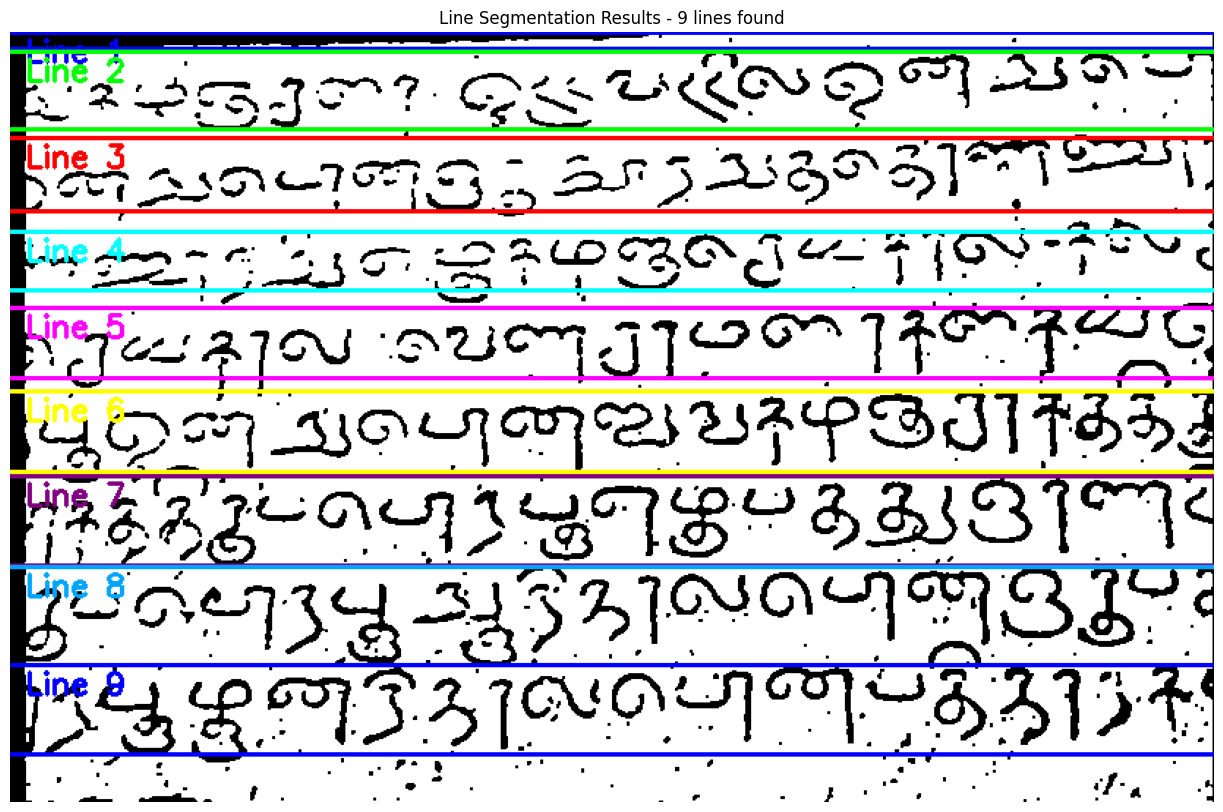


Displaying 157 segmented characters...


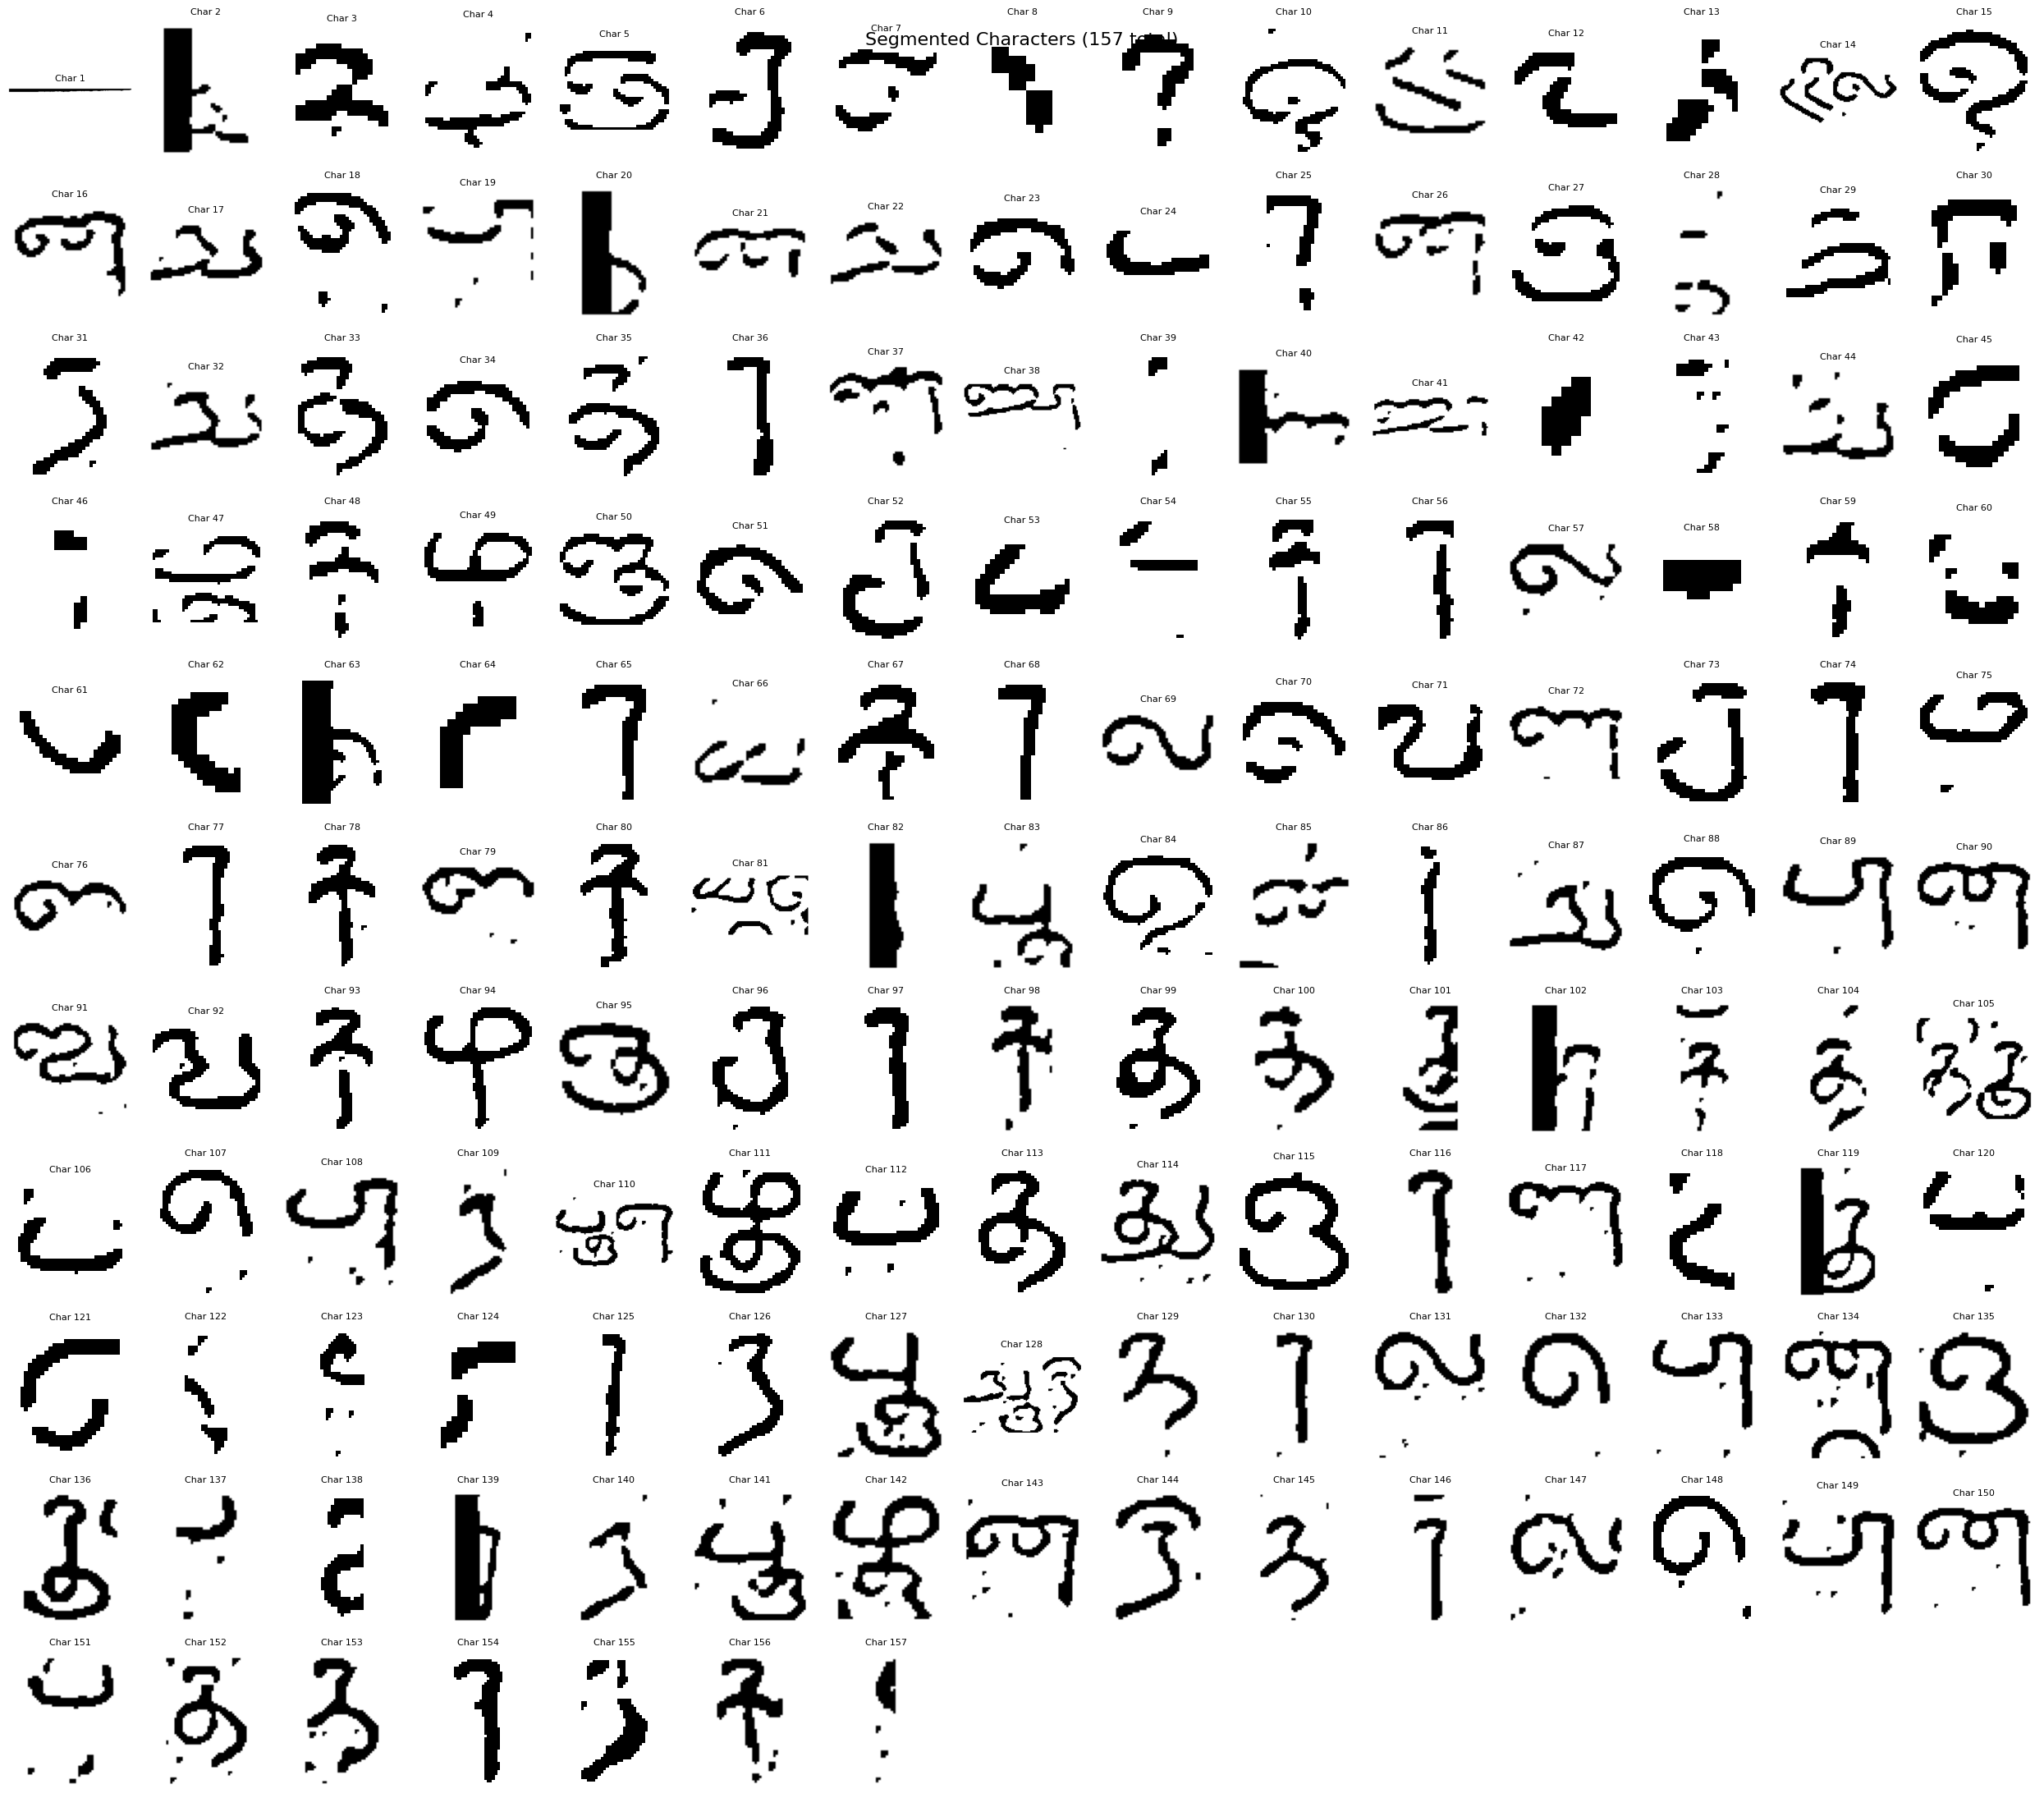


Showing character locations on original image...


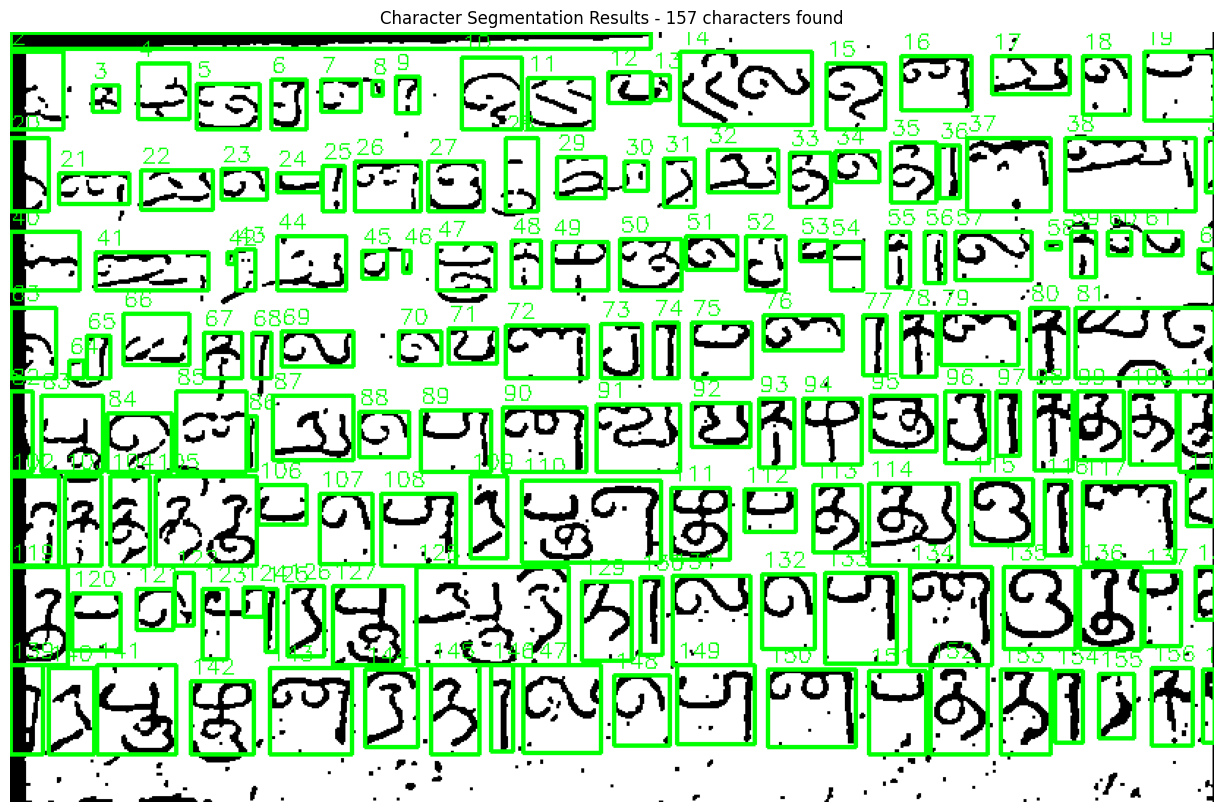


Creating zip file...
Created zip archive: segmented_characters_20251008_152002.zip

SEGMENTATION SUMMARY
Successfully segmented: 157 characters
Files saved in: advanced_segmented/
Zip file created: segmented_characters_20251008_152002.zip
Files named as: letter_001.png, letter_002.png, etc. (left to right)


/usr/lib/python3.12/zipfile/__init__.py:1611: UserWarning: Duplicate name: 'letter_012.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1611: UserWarning: Duplicate name: 'letter_011.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1611: UserWarning: Duplicate name: 'letter_009.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1611: UserWarning: Duplicate name: 'letter_014.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1611: UserWarning: Duplicate name: 'letter_017.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1611: UserWarning: Duplicate name: 'letter_007.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib/python3.12/zipfile/__init__.py:1611: UserWarning: Duplicate name: 'letter

In [ ]:
from datetime import datetime

def preprocess_image(image_path):
    """
    Enhanced preprocessing for better letter segmentation
    """
    # Read image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not load image from {image_path}")

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Check if inverted and correct if needed
    if np.mean(gray) < 127:
        gray = cv2.bitwise_not(gray)

    # Apply bilateral filter to reduce noise while keeping edges sharp
    filtered = cv2.bilateralFilter(gray, 9, 75, 75)

    # Apply adaptive threshold for better results with varying lighting
    binary = cv2.adaptiveThreshold(filtered, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 11, 2)

    # Alternative: Use Otsu's method
    _, binary_otsu = cv2.threshold(filtered, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Combine both methods (take the better one based on connectivity)
    if count_components(binary) > count_components(binary_otsu):
        binary = binary_otsu

    return binary, gray

def count_components(binary_img):
    """Count connected components to help choose better thresholding"""
    contours, _ = cv2.findContours(binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return len([c for c in contours if cv2.contourArea(c) > 20])

def line_segmentation(binary_image):
    """
    Original line segmentation method that works well
    """
    # Get horizontal projection (sum of pixels in each row)
    horizontal_proj = np.sum(binary_image == 0, axis=1)  # Count black pixels

    # Find line boundaries
    line_threshold = np.max(horizontal_proj) * 0.1  # Adjust threshold
    line_starts = []
    line_ends = []

    in_line = False
    for i, proj in enumerate(horizontal_proj):
        if proj > line_threshold and not in_line:
            line_starts.append(i)
            in_line = True
        elif proj <= line_threshold and in_line:
            line_ends.append(i)
            in_line = False

    # Handle case where line continues to end
    if in_line:
        line_ends.append(len(horizontal_proj))

    # Extract line images and check for overly tall lines that need splitting
    lines = []
    for start, end in zip(line_starts, line_ends):
        line_height = end - start
        if line_height > 10:  # Minimum line height
            if line_height > 80:  # This line might contain multiple text lines
                # Try to split this tall line
                split_lines = split_tall_line(binary_image, start, end, horizontal_proj)
                lines.extend(split_lines)
            else:
                # Normal height line
                line_img = binary_image[start:end, :]
                lines.append((line_img, start, end))

    return lines

def split_tall_line(binary_image, start, end, horizontal_proj):
    """
    Try to split a line that's too tall into multiple lines
    """
    line_region_proj = horizontal_proj[start:end]
    line_height = end - start

    # Look for local minima in the middle third of the line
    middle_start = line_height // 3
    middle_end = 2 * line_height // 3
    middle_region = line_region_proj[middle_start:middle_end]

    # Find the minimum value in the middle region
    if len(middle_region) > 0:
        min_val = np.min(middle_region)
        min_threshold = min_val + (np.max(line_region_proj) - min_val) * 0.2

        # Find potential split points
        potential_splits = []
        for i in range(1, len(middle_region) - 1):
            if (middle_region[i] <= min_threshold and
                middle_region[i] <= middle_region[i-1] and
                middle_region[i] <= middle_region[i+1]):
                actual_row = start + middle_start + i
                potential_splits.append(actual_row)

        if potential_splits:
            # Choose the split point closest to the middle
            middle_point = start + line_height // 2
            best_split = min(potential_splits, key=lambda x: abs(x - middle_point))

            # Create two separate lines
            lines = []

            # First line
            if best_split - start > 15:  # Ensure minimum height
                line1_img = binary_image[start:best_split, :]
                lines.append((line1_img, start, best_split))

            # Second line
            if end - best_split > 15:  # Ensure minimum height
                line2_img = binary_image[best_split:end, :]
                lines.append((line2_img, best_split, end))

            return lines if lines else [(binary_image[start:end, :], start, end)]

    # If no good split found, return original line
    return [(binary_image[start:end, :], start, end)]

def improved_character_segmentation(line_img, line_y_start=0, min_width=5, min_height=5):
    """
    Improved character segmentation within a line
    """
    # Clean the line image
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    cleaned = cv2.morphologyEx(line_img, cv2.MORPH_CLOSE, kernel)

    # Get vertical projection
    vertical_proj = np.sum(cleaned == 0, axis=0)  # Count black pixels in each column

    # Find character boundaries using vertical projection
    char_threshold = np.max(vertical_proj) * 0.05  # Lower threshold for character separation
    char_starts = []
    char_ends = []

    in_char = False
    for i, proj in enumerate(vertical_proj):
        if proj > char_threshold and not in_char:
            char_starts.append(i)
            in_char = True
        elif proj <= char_threshold and in_char:
            char_ends.append(i)
            in_char = False

    if in_char:
        char_ends.append(len(vertical_proj))

    # Extract characters and filter by size
    characters = []
    for start, end in zip(char_starts, char_ends):
        if end - start >= min_width:
            # Find actual character boundaries within this region
            char_region = cleaned[:, start:end]

            # Find vertical bounds of the character
            horizontal_proj = np.sum(char_region == 0, axis=1)
            non_zero_rows = np.where(horizontal_proj > 0)[0]

            if len(non_zero_rows) >= min_height:
                top = non_zero_rows[0]
                bottom = non_zero_rows[-1] + 1

                char_img = char_region[top:bottom, :]

                # Global coordinates
                global_x = start
                global_y = line_y_start + top
                global_w = end - start
                global_h = bottom - top

                characters.append((char_img, global_x, global_y, global_w, global_h))

    return characters

def advanced_segmentation_pipeline(image_path, output_folder="advanced_segmented", padding=3):
    """
    Advanced pipeline: Line segmentation -> Character segmentation -> save each line in its own folder
    """
    os.makedirs(output_folder, exist_ok=True)

    # Preprocess
    binary, original = preprocess_image(image_path)

    print(f"Image shape: {binary.shape}")

    # Segment into lines
    lines = line_segmentation(binary)
    print(f"Found {len(lines)} text lines")

    # Debug: Show line boundaries
    print("\nLine boundaries:")
    for i, (line_img, start, end) in enumerate(lines):
        print(f"  Line {i+1}: rows {start}-{end} (height: {end-start})")

    all_characters = []

    # Process each line
    for line_idx, (line_img, line_start, line_end) in enumerate(lines):
        print(f"\nProcessing line {line_idx + 1}...")

        # Create folder for each line
        line_folder = os.path.join(output_folder, f"line_{line_idx + 1}")
        os.makedirs(line_folder, exist_ok=True)

        # Segment characters in this line
        characters = improved_character_segmentation(line_img, line_start)
        print(f"  Found {len(characters)} characters in line {line_idx + 1}")

        # Save each character inside its line folder
        for char_idx, (char_img, x, y, w, h) in enumerate(characters, start=1):
            # Add padding
            padded_char = cv2.copyMakeBorder(
                char_img, padding, padding, padding, padding,
                cv2.BORDER_CONSTANT, value=255
            )

            filename = os.path.join(line_folder, f"letter_{char_idx:03d}.png")
            cv2.imwrite(filename, padded_char)
            all_characters.append((padded_char, x, y, w, h))

            print(f"    Saved {filename} (size: {w}x{h})")

    return all_characters, binary


def display_segmented_characters(characters, max_cols=15):
    """
    Display all segmented characters in a grid
    """
    if not characters:
        print("No characters to display")
        return

    num_chars = len(characters)
    cols = min(max_cols, num_chars)
    rows = (num_chars + cols - 1) // cols

    plt.figure(figsize=(25, 2 * rows))

    for i, (char_img, x, y, w, h) in enumerate(characters):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(char_img, cmap='gray')
        plt.title(f'Char {i+1}', fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.suptitle(f'Segmented Characters ({num_chars} total)', fontsize=16)
    plt.show()

def create_zip_from_folder(folder_path, zip_name=None):
    """Create zip file from folder"""
    if zip_name is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        zip_name = f"segmented_characters_{timestamp}.zip"

    with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                if file.endswith('.png'):
                    file_path = os.path.join(root, file)
                    zipf.write(file_path, file)

    print(f"Created zip archive: {zip_name}")
    return zip_name

def visualize_line_segmentation(binary_img, lines):
    """
    Visualize the line segmentation results
    """
    result_img = cv2.cvtColor(binary_img, cv2.COLOR_GRAY2BGR)

    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0),
              (255, 0, 255), (0, 255, 255), (128, 0, 128), (255, 165, 0)]

    for i, (line_img, start, end) in enumerate(lines):
        color = colors[i % len(colors)]
        # Draw line boundaries
        cv2.line(result_img, (0, start), (result_img.shape[1], start), color, 2)
        cv2.line(result_img, (0, end), (result_img.shape[1], end), color, 2)

        # Add line number
        cv2.putText(result_img, f'Line {i+1}', (10, start + 20),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    plt.figure(figsize=(20, 10))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.title(f'Line Segmentation Results - {len(lines)} lines found')
    plt.axis('off')
    plt.show()

def visualize_results(binary_img, characters):
    """
    Visualize the segmentation results
    """
    # Create image with bounding boxes
    result_img = cv2.cvtColor(binary_img, cv2.COLOR_GRAY2BGR)

    for i, (char_img, x, y, w, h) in enumerate(characters):
        # Draw bounding box
        cv2.rectangle(result_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        # Add character number
        cv2.putText(result_img, str(i+1), (x, y-5),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    plt.figure(figsize=(20, 10))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.title(f'Character Segmentation Results - {len(characters)} characters found')
    plt.axis('off')
    plt.show()

# Main execution
if __name__ == "__main__":
    image_path = "/content/text_cleaned.png"

    try:
        print("="*60)
        print("IMPROVED HANDWRITTEN TEXT SEGMENTATION")
        print("="*60)

        # Install required packages
        try:
            from scipy.signal import find_peaks
            from scipy import ndimage
        except ImportError:
            print("Installing required packages...")
            import subprocess
            subprocess.check_call(["pip", "install", "scipy", "scikit-image"])
            from scipy.signal import find_peaks
            from scipy import ndimage

        # Run advanced segmentation
        print("\nStarting advanced character segmentation...")
        characters, binary = advanced_segmentation_pipeline(image_path)

        if characters:
            # Show line segmentation first
            print("\nShowing line segmentation...")
            lines = line_segmentation(binary)
            visualize_line_segmentation(binary, lines)

            # Display results
            print(f"\nDisplaying {len(characters)} segmented characters...")
            display_segmented_characters(characters)

            # Show bounding boxes on original
            print("\nShowing character locations on original image...")
            visualize_results(binary, characters)

            # Create zip
            print("\nCreating zip file...")
            zip_path = create_zip_from_folder("advanced_segmented")

            # Summary
            print("\n" + "="*60)
            print("SEGMENTATION SUMMARY")
            print("="*60)
            print(f"Successfully segmented: {len(characters)} characters")
            print(f"Files saved in: advanced_segmented/")
            print(f"Zip file created: {zip_path}")
            print(f"Files named as: letter_001.png, letter_002.png, etc. (left to right)")
        else:
            print("No characters found. Try adjusting the parameters.")

    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()

# **ViT prediction + Word Matcher - Line Wise**

In [ ]:
class ViTPredictor:
    def __init__(self, vit_model_path, class_names, device='cuda'):
        self.class_names = class_names
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')
        self.vit_model = models.vit_b_16(pretrained=False)
        self.vit_model.heads = nn.Linear(self.vit_model.heads.head.in_features, len(class_names))
        self.vit_model.load_state_dict(torch.load(vit_model_path, map_location=self.device))
        self.vit_model.to(self.device)
        self.vit_model.eval()

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        ])

    def predict(self, image_path):
        image = Image.open(image_path).convert('RGB')
        image = self.transform(image).unsqueeze(0).to(self.device)
        with torch.no_grad():
            output = self.vit_model(image)
            probs = torch.nn.functional.softmax(output[0], dim=0)
            idx = torch.argmax(probs).item()
        return self.class_names[idx]


def predict_lines(folder_path, predictor):
    line_folders = sorted([f for f in os.listdir(folder_path) if f.startswith("line_")])
    predicted_lines = []

    for line_folder in line_folders:
        line_path = os.path.join(folder_path, line_folder)
        images = sorted([f for f in os.listdir(line_path) if f.endswith(".png")])

        line_text = ""
        for img_name in images:
            img_path = os.path.join(line_path, img_name)
            predicted = predictor.predict(img_path)
            line_text += predicted

        line_text = re.sub(r'Extra-|\d|[.\s]', '', line_text, flags=re.IGNORECASE)
        print(f"Line {line_folder.split('_')[1]}: {line_text}")
        predicted_lines.append(line_text)

    return predicted_lines


class TamilInscriptionAnalyzer:
    def __init__(self, excel_file_path):
        """
        Initialize with dictionary data from Excel file
        excel_file_path: path to Excel file with columns 'Old_Tamil', 'New_Tamil', 'Meaning'
        """
        self.dictionary = self._load_excel_dictionary(excel_file_path)
        self.word_index = self._build_word_index()
        print(f"Loaded {len(self.dictionary)} dictionary entries")

    def _load_excel_dictionary(self, file_path):
        """Load dictionary from Excel file"""
        try:
            df = pd.read_excel(file_path)

            # Handle different possible column names
            column_mapping = {
                'Old_Tamil': ['Old_Tamil', 'old_tamil', 'Old Tamil', 'OldTamil'],
                'New_Tamil': ['New_Tamil', 'new_tamil', 'New Tamil', 'NewTamil', 'Modern_Tamil', 'modern_tamil'],
                'Meaning': ['Meaning', 'meaning', 'English', 'english', 'Definition', 'definition']
            }

            # Find correct column names
            actual_columns = {}
            for standard_name, possible_names in column_mapping.items():
                for possible_name in possible_names:
                    if possible_name in df.columns:
                        actual_columns[standard_name] = possible_name
                        break

                if standard_name not in actual_columns:
                    actual_columns[standard_name] = None

            # Convert to dictionary format
            dictionary = []
            for _, row in df.iterrows():
                entry = {}

                if actual_columns['Old_Tamil']:
                    old_tamil = str(row[actual_columns['Old_Tamil']]) if pd.notna(row[actual_columns['Old_Tamil']]) else ''
                    entry['old_tamil'] = old_tamil.strip()
                else:
                    entry['old_tamil'] = ''

                if actual_columns['New_Tamil']:
                    new_tamil = str(row[actual_columns['New_Tamil']]) if pd.notna(row[actual_columns['New_Tamil']]) else ''
                    entry['modern_tamil'] = new_tamil.strip()
                else:
                    entry['modern_tamil'] = ''

                if actual_columns['Meaning']:
                    meaning = str(row[actual_columns['Meaning']]) if pd.notna(row[actual_columns['Meaning']]) else ''
                    entry['english'] = meaning.strip()
                else:
                    entry['english'] = ''

                # Only add entries with at least old Tamil text
                if entry['old_tamil'] and entry['old_tamil'] != 'nan':
                    dictionary.append(entry)

            return dictionary

        except Exception as e:
            print(f"Error loading Excel file: {e}")
            raise

    def _build_word_index(self):
        """Build an index for faster word lookup - includes both Old and New Tamil"""
        index = defaultdict(list)
        for i, entry in enumerate(self.dictionary):
            # Index Old Tamil words
            old_word = self._normalize_tamil(entry.get('old_tamil', ''))
            if old_word:
                index[len(old_word)].append((old_word, i, 'old'))
                index[f"first_{old_word[0]}"].append((old_word, i, 'old'))

            # Index New/Modern Tamil words
            new_word = self._normalize_tamil(entry.get('modern_tamil', ''))
            if new_word and new_word != old_word:  # Avoid duplicates
                index[len(new_word)].append((new_word, i, 'modern'))
                index[f"first_{new_word[0]}"].append((new_word, i, 'modern'))

        return index

    def _normalize_tamil(self, text):
        """Normalize Tamil text for better matching"""
        if not text or text == 'nan':
            return ""
        normalized = unicodedata.normalize('NFKD', str(text))
        cleaned = re.sub(r'[^\u0B80-\u0BFF]', '', normalized)
        return cleaned.strip()

    def _calculate_similarity(self, str1, str2):
        """Calculate similarity between two strings"""
        if not str1 or not str2:
            return 0.0

        similarity = SequenceMatcher(None, str1, str2).ratio()

        if str1 == str2:
            return 1.0

        # Bonus for substring matches
        if str1 in str2 or str2 in str1:
            shorter = min(str1, str2, key=len)
            longer = max(str1, str2, key=len)
            containment_bonus = len(shorter) / len(longer) * 0.3
            similarity = min(1.0, similarity + containment_bonus)

        # Length penalty
        len_diff = abs(len(str1) - len(str2))
        max_len = max(len(str1), len(str2))
        if max_len > 0:
            length_penalty = len_diff / max_len * 0.1
            similarity = max(0, similarity - length_penalty)

        return similarity

    def _find_candidate_words(self, text_segment, min_similarity=0.6):
        """Find candidate words that might match the text segment"""
        normalized_segment = self._normalize_tamil(text_segment)
        candidates = []

        if not normalized_segment:
            return candidates

        # Look for words of similar length
        target_len = len(normalized_segment)
        for check_len in range(max(1, target_len - 3), target_len + 4):
            if check_len in self.word_index:
                for word, dict_index, word_type in self.word_index[check_len]:
                    similarity = self._calculate_similarity(normalized_segment, word)
                    if similarity >= min_similarity:
                        candidates.append((word, dict_index, similarity, word_type))

        # Check words with same first character
        if normalized_segment:
            first_char_key = f"first_{normalized_segment[0]}"
            if first_char_key in self.word_index:
                for word, dict_index, word_type in self.word_index[first_char_key]:
                    similarity = self._calculate_similarity(normalized_segment, word)
                    if similarity >= min_similarity:
                        candidates.append((word, dict_index, similarity, word_type))

        # Remove duplicates and sort by similarity
        seen = set()
        unique_candidates = []
        for word, dict_index, similarity, word_type in candidates:
            if (dict_index, word_type) not in seen:
                seen.add((dict_index, word_type))
                unique_candidates.append((word, dict_index, similarity, word_type))

        return sorted(unique_candidates, key=lambda x: x[2], reverse=True)

    def segment_text(self, continuous_text, max_word_length=20, min_word_length=2):
        """Segment continuous text into potential words"""
        normalized_text = self._normalize_tamil(continuous_text)
        n = len(normalized_text)

        if n == 0:
            return []

        # Dynamic programming for optimal segmentation
        dp = [(0, [])] * (n + 1)

        for i in range(1, n + 1):
            for j in range(max(0, i - max_word_length), i):
                if i - j < min_word_length:
                    continue

                segment = normalized_text[j:i]
                candidates = self._find_candidate_words(segment, min_similarity=0.4)

                if candidates:
                    best_similarity = candidates[0][2]
                    word_score = best_similarity * (i - j)
                    total_score = dp[j][0] + word_score

                    if total_score > dp[i][0]:
                        dp[i] = (total_score, dp[j][1] + [(j, i, segment, candidates[0])])
                else:
                    fallback_score = dp[j][0] + (i - j) * 0.1
                    if fallback_score > dp[i][0]:
                        no_match = (segment, -1, 0.0, 'none')
                        dp[i] = (fallback_score, dp[j][1] + [(j, i, segment, no_match)])

        return dp[n][1] if dp[n][1] else self._fallback_segmentation(normalized_text)

    def _fallback_segmentation(self, text, chunk_size=4):
        """Fallback segmentation when dynamic programming fails"""
        segments = []
        for i in range(0, len(text), chunk_size):
            end = min(i + chunk_size, len(text))
            segment = text[i:end]
            candidates = self._find_candidate_words(segment, min_similarity=0.2)
            best_candidate = candidates[0] if candidates else (segment, -1, 0.0, 'none')
            segments.append((i, end, segment, best_candidate))
        return segments

    def analyze_inscription(self, continuous_text, min_similarity=0.5):
        """Main function to analyze continuous inscription text"""
        print(f"Analyzing text: {continuous_text[:50]}...")

        segments = self.segment_text(continuous_text)
        results = []
        unidentified_segments = []

        for start, end, segment, best_match in segments:
            word, dict_index, similarity, word_type = best_match

            if dict_index >= 0 and similarity >= min_similarity:
                dict_entry = self.dictionary[dict_index]
                result = {
                    'position': (start, end),
                    'original_segment': segment,
                    'matched_word': word,
                    'similarity': round(similarity, 3),
                    'match_type': word_type,
                    'old_tamil': dict_entry.get('old_tamil', ''),
                    'modern_tamil': dict_entry.get('modern_tamil', ''),
                    'english': dict_entry.get('english', ''),
                    'confidence': 'high' if similarity > 0.8 else 'medium' if similarity > 0.65 else 'low'
                }
                results.append(result)
            else:
                unidentified_segments.append({
                    'position': (start, end),
                    'segment': segment,
                    'best_similarity': round(similarity, 3) if dict_index >= 0 else 0.0
                })

        return {
            'original_text': continuous_text,
            'identified_words': results,
            'unidentified_segments': unidentified_segments,
            'total_segments': len(segments),
            'identification_rate': len(results) / len(segments) if segments else 0
        }

    def print_results(self, result):
        """Print analysis results"""
        print(f"\nOriginal text: {result['original_text']}")
        print(f"Identification rate: {result['identification_rate']:.2%}")
        print(f"Identified words: {len(result['identified_words'])}")

        print("\nIDENTIFIED WORDS:")
        print("=" * 50)

        for i, word in enumerate(result['identified_words'], 1):
            print(f"{i}. '{word['original_segment']}' → {word['matched_word']} [{word['match_type']}]")
            print(f"   Old: {word['old_tamil']} | Modern: {word['modern_tamil']}")
            print(f"   English: {word['english']}")
            print(f"   Similarity: {word['similarity']} | Confidence: {word['confidence']}")
            print()

        if result['unidentified_segments']:
            print("UNIDENTIFIED SEGMENTS:")
            for seg in result['unidentified_segments']:
                print(f"  '{seg['segment']}' at position {seg['position']}")


if __name__ == "__main__":
    vit_path = "/content/drive/MyDrive/SEMESTER 5/Tamil Inscription Reader/Character Recognition - Model Training/VIT_classifier.pth"
    class_names = ['0. ா', '1. ெ', '10. ஏ', '11. ஐ', '12. ஒ', '13.1. க', '13.2. கி', '13.4. கு', '13.5. கூ', '14.1. ச', '14.2. சி', '14.4. சு', '15.1. ட', '15.2. டி', '15.4. டு', '16.1. த', '16.2. தி', '16.3. தீ', '16.4. து', '16.5. தூ', '17.1. ப', '17.2. பி', '17.3. பீ', '17.4. பு', '17.5. பூ', '18.1. ற', '18.2. றி', '18.4. று', '18.6. று', '19.1. ங', '20.1. ஞ', '21.1. ண', '21.2. ணி', '21.4. ணு', '21.6. Extra - ண', '22.1. ந', '22.2. நி', '22.3. நீ', '23.1. ம', '23.2. மி', '23.4. மு', '24.1. ன', '24.2. னி', '24.4. னு', '24.5. னூ', '24.6. Extra - ன', '25.1. ய', '25.2. யி', '25.4. யு', '26.1. ர', '26.2. ரி', '26.4. ரு', '27.1. ல', '27.2. லி', '27.4. லு', '27.6. Extra - ல', '28.1. வ', '28.2. வி', '28.3. வீ', '28.4. வு', '29.1. ழ', '29.2. ழி', '29.4. ழு', '3. அ', '3. ை', '30.1. ள', '30.2. ளி', '4. ஆ', '5. இ', '6. ஈ', '7. உ', '8. ஊ', '9. எ']

    vit_predictor = ViTPredictor(vit_path, class_names)
    segmented_folder = "advanced_segmented"
    predicted_lines = predict_lines(segmented_folder, vit_predictor)

    # Now analyze meanings
    analyzer = TamilInscriptionAnalyzer("/content/drive/MyDrive/SEMESTER 5/Tamil Inscription Reader/Meanings/NLP Dataset (1 to 40 and 101 to 140).xlsx")

    # NEW: Create array to store English keywords for each line
    english_keywords_per_line = []

    for i, line_text in enumerate(predicted_lines, 1):
        result = analyzer.analyze_inscription(line_text)

        # Print results
        analyzer.print_results(result)

        # NEW: Extract English keywords for this line
        line_keywords = []
        for word_info in result['identified_words']:
            english_meaning = word_info.get('english', '').strip()
            if english_meaning:  # Only add non-empty meanings
                line_keywords.append(english_meaning)

        english_keywords_per_line.append(line_keywords)

    # NEW: Print all English keywords per line
    print("\n" + "=" * 70)
    print("ENGLISH KEYWORDS PER LINE:")
    print("=" * 70)
    for i, keywords in enumerate(english_keywords_per_line, 1):
        print(f"\nLine {i} Keywords ({len(keywords)} words):")
        print(f"  {keywords}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Line 1: ட
Line 2: ஊசுநிறுயிறுசிநழிறுபிநிஐெனயிழிழி
Line 3: நளறிெறழிஒமிறிநறிறழிதெழிாசிகூட
Line 4: பூறுபஊயிெஈநீநிரிறுெறுபஉநிஊழிபநிறிறரு
Line 5: ஒராயிநீாலெலளயிாழிளாசுழிநீறி
Line 6: பதிெஊசிழிெபுனஐவசுமுனுறுாசுதிதகு
Line 7: ஒஊதிதிழிமிழிநிளிகுழிததுஇாளற
Line 8: திழிெநிழிநாறஞதிறாலெழினுமிகுழிபி
Line 9: சறிழிதினழிறிாறிெயினநிதிறிாறிகிழி
Loaded 1531 dictionary entries
Analyzing text: ட...

Original text: ட
Identification rate: 100.00%
Identified words: 1

IDENTIFIED WORDS:
1. 'ட' → ஆடு [modern]
   Old: அசம் | Modern: ஆடு
   English: goat
   Similarity: 0.533 | Confidence: low

Analyzing text: ஊசுநிறுயிறுசிநழிறுபிநிஐெனயிழிழி...

Original text: ஊசுநிறுயிறுசிநழிறுபிநிஐெனயிழிழி
Identification rate: 100.00%
Identified words: 12

IDENTIFIED WORDS:
1. 'ஊசு' → ஏசு [old]
   Old: ஏசு | Modern: ஏசென்னேவல்
   English: revile
   Similarity: 0.667 | Confidence: medium

2. 'நி' → அநாதி [old]
   Old: அநாதி | Modern: கடவுள்
   English: the Deity
   Similarity: 0.511 | Confidence: low

3. 'று' → ஆறு [modern]
   Old: 

# **Sentence Generation**

In [ ]:
# Path where you saved your trained model
MODEL_DIR = "/content/drive/MyDrive/SEMESTER 5/Tamil Inscription Reader/Keyword to sentence/fine_tuned_t5_model"

# Load model and tokenizer
tokenizer = T5Tokenizer.from_pretrained(MODEL_DIR)
model = T5ForConditionalGeneration.from_pretrained(MODEL_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def generate_sentence_from_keywords(keywords, max_length=50, num_beams=5):
    # Prepare input text with the same prefix used in training
    input_text = f"generate sentence from keywords: {keywords}"

    # Tokenize input
    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        max_length=128,
        truncation=True,
        padding="max_length"
    ).to(device)

    # Generate output
    output_ids = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=max_length,
        num_beams=num_beams,
        early_stopping=True
    )

    # Decode to text
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

# Example usage
Sentences = []
y = len(english_keywords_per_line)
for i in range (0,y):
  keywords = english_keywords_per_line[i]
  keywords = " ".join(keywords)
  sentence = generate_sentence_from_keywords(keywords)
  print("Generated sentence:", sentence)

  Sentences.append(sentence)


Generated sentence: A goat is a goat.
Generated sentence: The Deity may revile a river a sneer saltpans a monkey the Deity mustard saltpans saltpans saltpans saltpans a rope.
Generated sentence: The forehead a wild hog the forehead saltpans the thighs saltpans the south impossibility.
Generated sentence: The Deity a large tank a river south a chisel saltpans others a rope fetus.
Generated sentence: A birth gateway water mountain paddy is a water-pot. A poem reviles saltpans water a wild hog.
Generated sentence: The Brahmany kite a king revile the breast of a woman my a river revile an augmentative prefix & thin flat plate of metal.
Generated sentence: Odim Woodier an augmentative prefix saltpans companion saltpans a form of the sixth or possessive case singular night.
Generated sentence: An augmentative prefix saltpans a dog. forgetfulness garland saltpans a monkey saltpans.
Generated sentence: In the thirteenth lunar asterism, a sneer saltpans an augmentative prefix saltpans forgetful

# **Sentence Translation**

In [ ]:
from transformers import MarianMTModel, MarianTokenizer
import torch

# Path to your saved fine-tuned model and tokenizer
save_path = "/content/drive/MyDrive/SEMESTER 5/Tamil Inscription Reader/Translation - English to Tamil/Model/marian-en-ta-final/marian-en-ta-final_100k"

# Load the fine-tuned model and tokenizer
tokenizer = MarianTokenizer.from_pretrained(save_path)
model = MarianMTModel.from_pretrained(save_path)

# Setup device
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

def translate(text):
    """Translate English text to Tamil"""
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        generated_tokens = model.generate(**inputs, max_length=128, num_beams=5)
    translation = tokenizer.decode(generated_tokens[0], skip_special_tokens=True)
    return translation


for sentence in Sentences:
    print(f"English: {sentence}")
    print(f"Tamil:   {translate(sentence)}\n")


English: A goat is a goat.
Tamil:   ஓர் ஆட்டம் ஒரு ஆடு.

English: The Deity may revile a river a sneer saltpans a monkey the Deity mustard saltpans saltpans saltpans saltpans a rope.
Tamil:   டெய்ட்டி ஒரு கயிற்றின் உப்புப் பஞ்சின் டீடி மூச்சு உப்புப் பானங்கள் ஒரு கயிற்றை ஒரு கயிற்றில் சுப்பின் உப்பு சாப்பான்களைக் குறைத்து வரலாம்.

English: The forehead a wild hog the forehead saltpans the thighs saltpans the south impossibility.
Tamil:   தெற்குத் திறக்கூடிய உப்பானிகளின் முகம் ஒரு காலியான முகம் உப்புப் பாகங்களைக் கொதித்துள்ளது.

English: The Deity a large tank a river south a chisel saltpans others a rope fetus.
Tamil:   தெற்கு ஆற்றில் ஒரு பெரிய டான்க் ஒரு கயிற்றின் உப்பாக்கிகள் மற்றும் ஒரு கயிற்றின் குழந்தை.

English: A birth gateway water mountain paddy is a water-pot. A poem reviles saltpans water a wild hog.
Tamil:   பிறந்த ஒரு வாயிலின் வாயிலான நீர் வாயிலாகும் மலையின் வாயிலானது ஒரு தண்ணீர் பாத்திரமாகும்.

English: The Brahmany kite a king revile the breast of a woman my a river revi